In [ ]:
!pip install opencv-python scikit-image matplotlib pandas numpy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import glob
import random
import time
from collections import Counter, defaultdict
from skimage.feature import hog, local_binary_pattern

np.random.seed(42)
random.seed(42)

print('All libraries imported successfully!')
print(f'   NumPy     : {np.__version__}')
print(f'   Pandas    : {pd.__version__}')
print(f'   OpenCV    : {cv2.__version__}')

All libraries imported successfully!
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   OpenCV    : 4.13.0


In [ ]:
import os
from google.colab import drive

print(" Mounting Google Drive...")
drive.mount('/content/drive')


rar_path = '/content/drive/MyDrive/6thsem/ml/dataset-resized.rar'
extract_path = '/content/'

print(f"\n Extracting data from Drive... (isme thora time lag sakta hai)")
!unrar x -Y "{rar_path}" "{extract_path}" > /dev/null

DATA_DIR = '/content/dataset-resized'
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

if os.path.exists(DATA_DIR):
    found_classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    print(f'\n Dataset successfully extracted!')
    print(f' Data directory located at: {DATA_DIR}')
    print(f'  Classes found: {found_classes}')
else:
    print('\n Error: Folder extract nahi hua. Drive ka path check karein.')

 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Extracting data from Drive... (isme thora time lag sakta hai)

 Dataset successfully extracted!
 Data directory located at: /content/dataset-resized
  Classes found: ['metal', 'plastic', 'cardboard', 'glass', 'paper', 'trash']


In [ ]:
import os

DATASET_ROOT = '/content/dataset-resized'

for root, dirs, files_list in os.walk(DATASET_ROOT):
    depth = root.replace(DATASET_ROOT, '').count(os.sep)
    if depth > 2:
        break
    indent = '│   ' * depth
    print(f'{indent} {os.path.basename(root)}/')
    if depth == 1:
        sub_indent = '│   ' * (depth + 1)
        for f in files_list[:3]:
            print(f'{sub_indent}  {f}')
        if len(files_list) > 3:
            print(f'{sub_indent}... and {len(files_list)-3} more images')

CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

DATA_DIR = None
for root, dirs, _ in os.walk(DATASET_ROOT):
    if any(c in dirs for c in CLASS_NAMES):
        DATA_DIR = root
        break

if DATA_DIR is None:
    DATA_DIR = DATASET_ROOT

print(f'\n  Data directory located at: {DATA_DIR}')
print(f' Classes found: {[d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR,d))]}')

📁 dataset-resized/
│   📁 metal/
│   │   🖼️  metal312.jpg
│   │   🖼️  metal128.jpg
│   │   🖼️  metal317.jpg
│   │   ... and 407 more images
│   📁 plastic/
│   │   🖼️  plastic86.jpg
│   │   🖼️  plastic120.jpg
│   │   🖼️  plastic235.jpg
│   │   ... and 479 more images
│   📁 cardboard/
│   │   🖼️  cardboard80.jpg
│   │   🖼️  cardboard391.jpg
│   │   🖼️  cardboard85.jpg
│   │   ... and 400 more images
│   📁 glass/
│   │   🖼️  glass51.jpg
│   │   🖼️  glass56.jpg
│   │   🖼️  glass283.jpg
│   │   ... and 498 more images
│   📁 paper/
│   │   🖼️  paper61.jpg
│   │   🖼️  paper93.jpg
│   │   🖼️  paper15.jpg
│   │   ... and 591 more images
│   📁 trash/
│   │   🖼️  trash3.jpg
│   │   🖼️  trash86.jpg
│   │   🖼️  trash72.jpg
│   │   ... and 134 more images

📂 Data directory located at: /content/dataset-resized
📋 Classes found: ['metal', 'plastic', 'cardboard', 'glass', 'paper', 'trash']


---
##  PART 2 — Exploratory Data Analysis (EDA)

Before training any model, we must **understand the data** deeply.

We will explore:
- Class distribution (how many images per class)
- Image dimensions
- Sample images per class
- RGB channel histograms
- Pixel intensity distributions
- Duplicate and missing value checks
- Class imbalance analysis

In [ ]:
class_image_counts = {}
all_image_paths    = []
all_labels         = []

for cls in CLASS_NAMES:
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_path):
        print(f'  Folder not found: {cls_path}')
        class_image_counts[cls] = 0
        continue
    imgs = glob.glob(os.path.join(cls_path, '*.jpg')) + \
           glob.glob(os.path.join(cls_path, '*.jpeg')) + \
           glob.glob(os.path.join(cls_path, '*.png'))
    class_image_counts[cls] = len(imgs)
    all_image_paths.extend(imgs)
    all_labels.extend([cls] * len(imgs))

total_images = sum(class_image_counts.values())

print('=' * 45)
print(f'  TrashNet Dataset — Summary')
print('=' * 45)
print(f'  Total images : {total_images}')
print(f'  Total classes: {len(CLASS_NAMES)}')
print('-' * 45)
for cls, cnt in class_image_counts.items():
    pct = cnt / total_images * 100
    bar = '' * int(pct / 2)
    print(f'  {cls:<12}: {cnt:>4} images  ({pct:.1f}%)  {bar}')
print('=' * 45)

  TrashNet Dataset — Summary
  Total images : 2527
  Total classes: 6
---------------------------------------------
  cardboard   :  403 images  (15.9%)  
  glass       :  501 images  (19.8%)  
  metal       :  410 images  (16.2%)  
  paper       :  594 images  (23.5%)  
  plastic     :  482 images  (19.1%)  
  trash       :  137 images  (5.4%)  


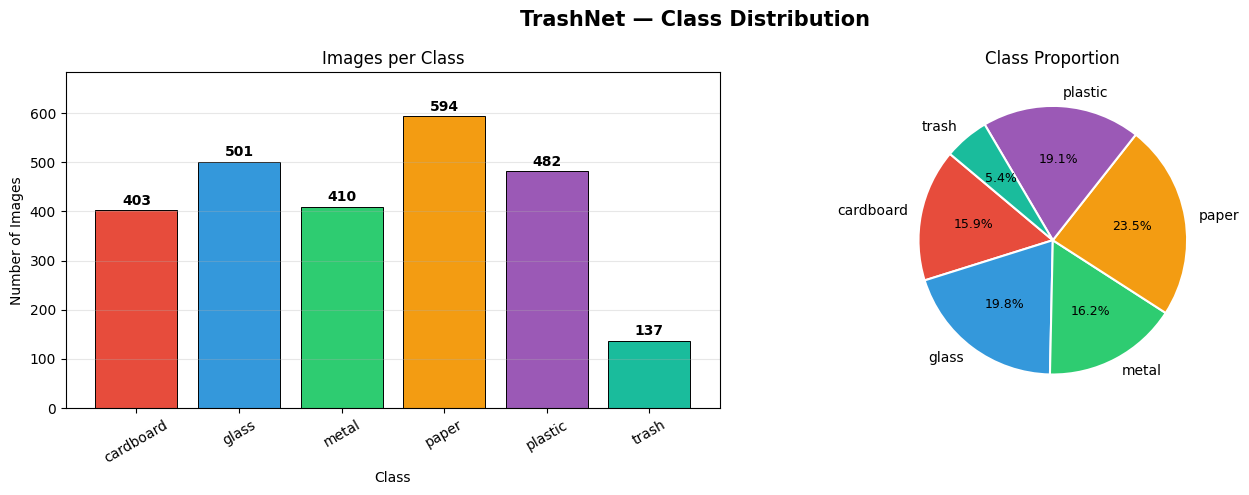

Class distribution chart saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TrashNet — Class Distribution', fontsize=15, fontweight='bold')

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

bars = axes[0].bar(CLASS_NAMES,
                   [class_image_counts[c] for c in CLASS_NAMES],
                   color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Images per Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, max(class_image_counts.values()) * 1.15)
for bar, cnt in zip(bars, [class_image_counts[c] for c in CLASS_NAMES]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(cnt),
                 ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

wedges, texts, autotexts = axes[1].pie(
    [class_image_counts[c] for c in CLASS_NAMES],
    labels=CLASS_NAMES,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Class Proportion')
for at in autotexts:
    at.set_fontsize(9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class distribution chart saved.')

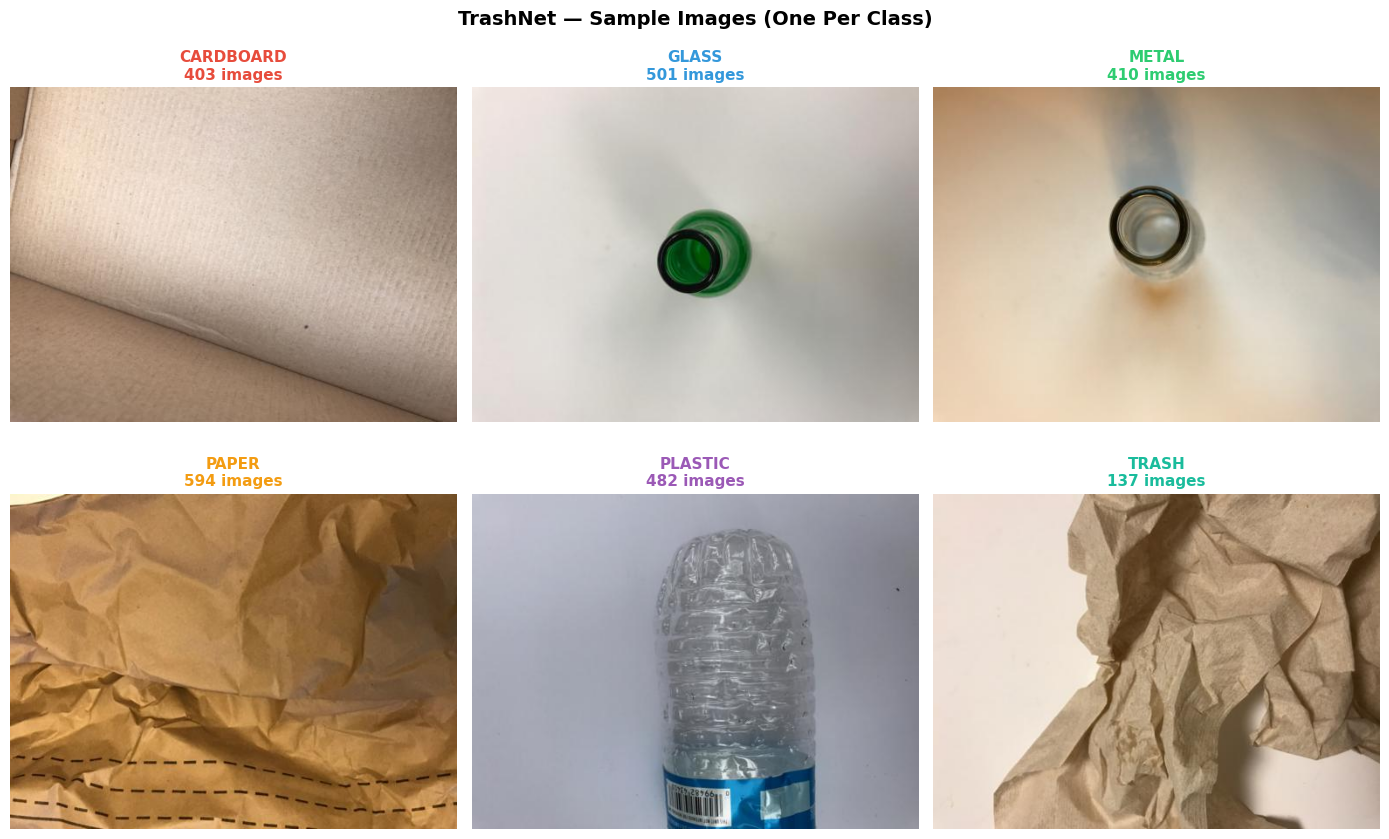

 Sample images displayed.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('TrashNet — Sample Images (One Per Class)', fontsize=14, fontweight='bold')

for ax, cls, color in zip(axes.flat, CLASS_NAMES, colors):
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = glob.glob(os.path.join(cls_path, '*.jpg')) + \
           glob.glob(os.path.join(cls_path, '*.jpeg')) + \
           glob.glob(os.path.join(cls_path, '*.png'))
    if not imgs:
        ax.set_visible(False)
        continue
    img_path = random.choice(imgs)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f'{cls.upper()}\n{class_image_counts[cls]} images',
                 fontweight='bold', color=color, fontsize=11)
    ax.axis('off')

    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sample images displayed.')

Image Dimension Statistics (sample of 300):
  Width  — min:512, max:512, mean:512
  Height — min:384, max:384, mean:384


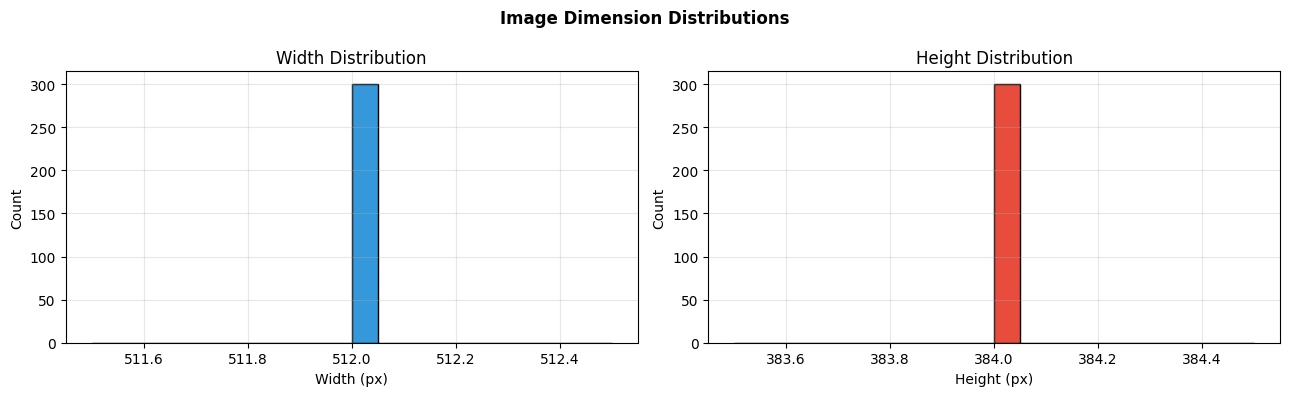

In [ ]:
sample_paths = random.sample(all_image_paths, min(300, len(all_image_paths)))
widths, heights = [], []

for p in sample_paths:
    img = cv2.imread(p)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print('Image Dimension Statistics (sample of 300):')
print(f'  Width  — min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}')
print(f'  Height — min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(widths,  bins=20, color='#3498db', edgecolor='black')
axes[0].set_title('Width Distribution');  axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=20, color='#e74c3c', edgecolor='black')
axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Height (px)')
for ax in axes:
    ax.set_ylabel('Count'); ax.grid(alpha=0.3)
plt.suptitle('Image Dimension Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

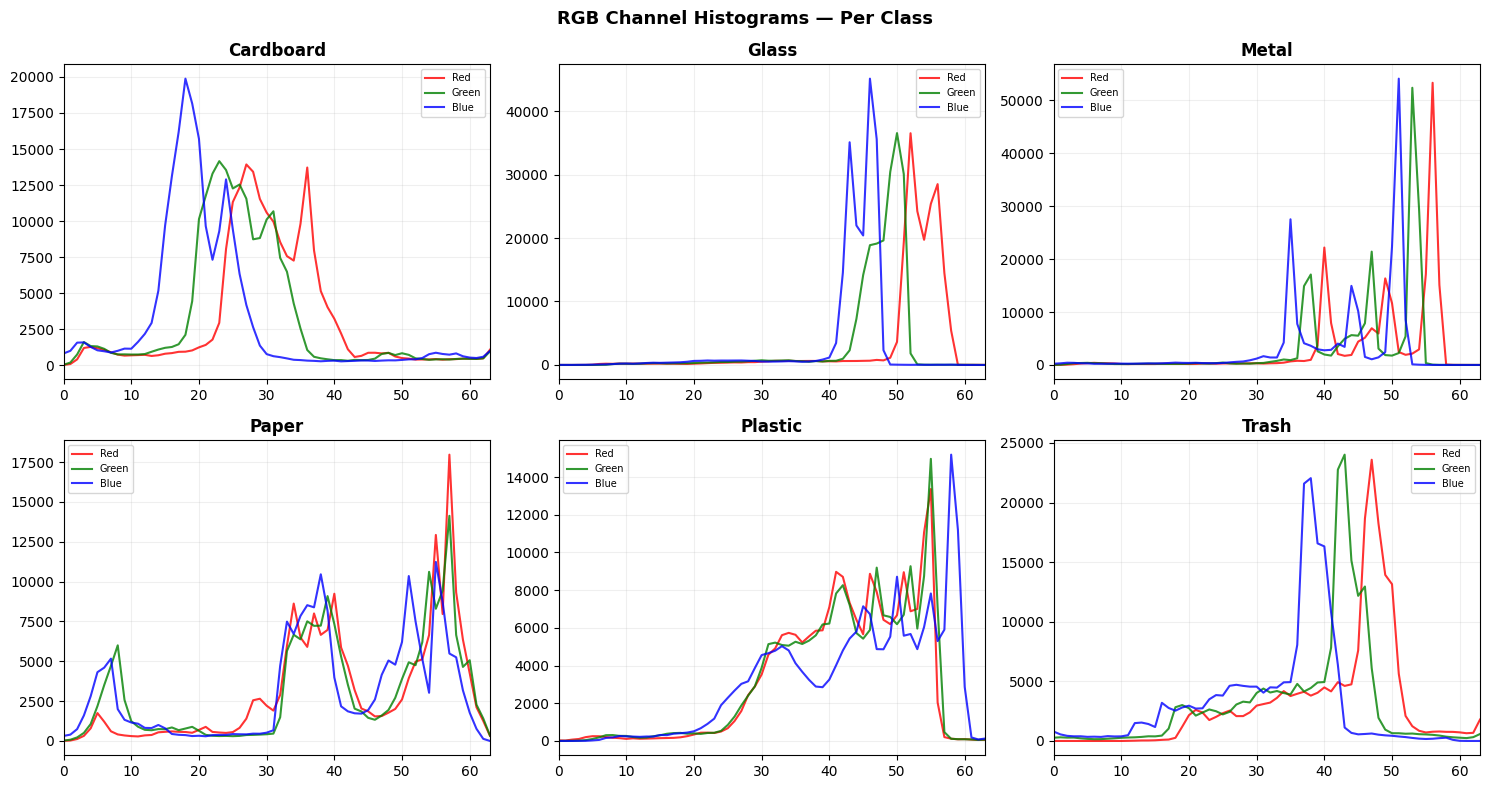

RGB histograms plotted.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('RGB Channel Histograms — Per Class', fontsize=13, fontweight='bold')
channel_colors = ('r', 'g', 'b')
channel_names  = ('Red', 'Green', 'Blue')

for ax, cls in zip(axes.flat, CLASS_NAMES):
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = glob.glob(os.path.join(cls_path, '*.jpg')) + \
           glob.glob(os.path.join(cls_path, '*.jpeg')) + \
           glob.glob(os.path.join(cls_path, '*.png'))
    img = cv2.imread(random.choice(imgs))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for ch, col, name in zip(range(3), channel_colors, channel_names):
        hist = np.histogram(img_rgb[:,:,ch].ravel(), bins=64, range=(0,256))[0]
        ax.plot(hist, color=col, label=name, alpha=0.8, linewidth=1.5)
    ax.set_title(f'{cls.capitalize()}', fontweight='bold')
    ax.set_xlim(0, 63); ax.grid(alpha=0.2)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('rgb_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('RGB histograms plotted.')

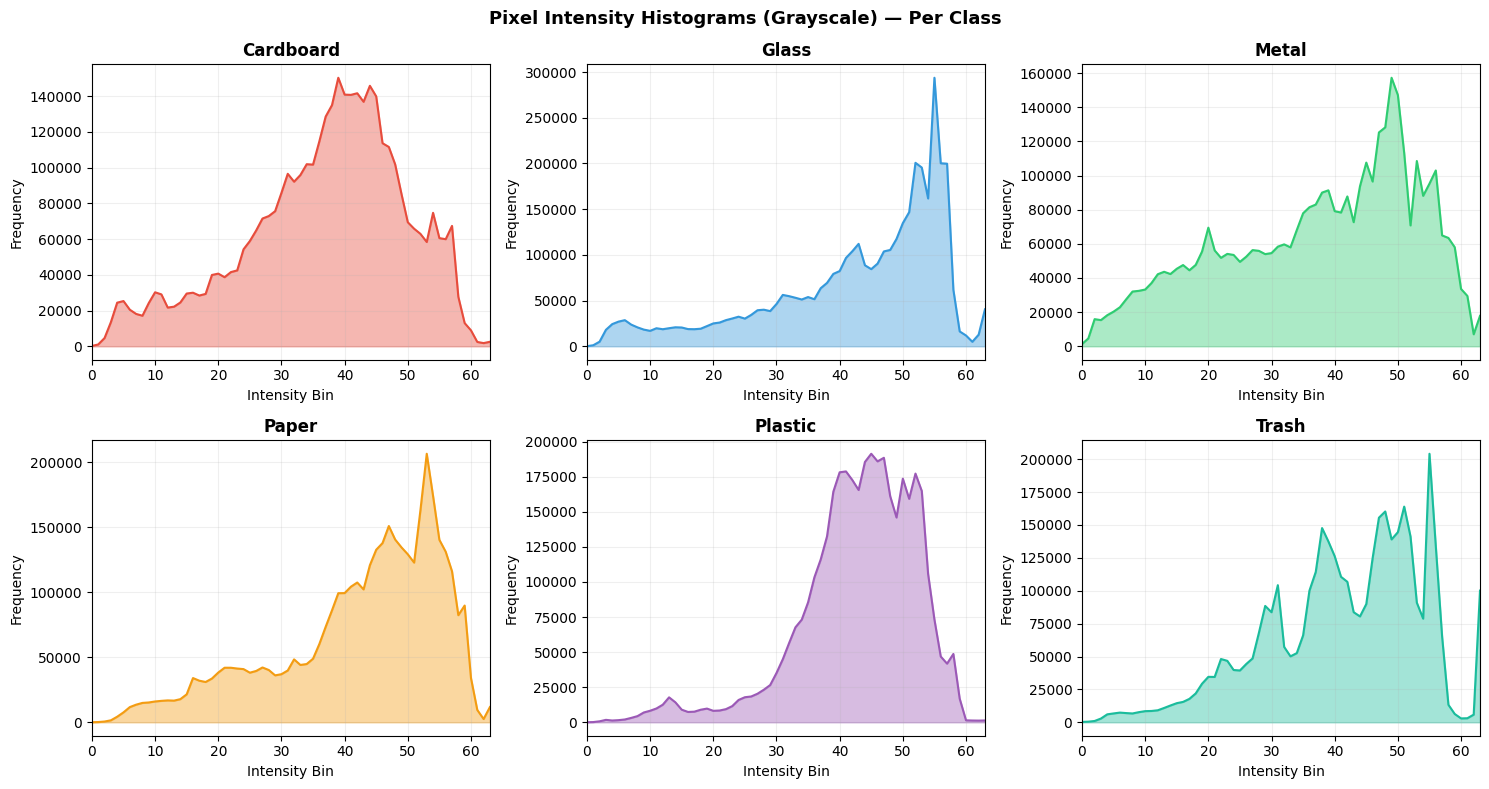

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Pixel Intensity Histograms (Grayscale) — Per Class',
             fontsize=13, fontweight='bold')

for ax, cls, color in zip(axes.flat, CLASS_NAMES, colors):
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = glob.glob(os.path.join(cls_path, '*.jpg')) + \
           glob.glob(os.path.join(cls_path, '*.jpeg')) + \
           glob.glob(os.path.join(cls_path, '*.png'))
    sample = random.sample(imgs, min(20, len(imgs)))
    agg_hist = np.zeros(64)
    for p in sample:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            h = np.histogram(img.ravel(), bins=64, range=(0,256))[0]
            agg_hist += h
    ax.fill_between(range(64), agg_hist, alpha=0.4, color=color)
    ax.plot(agg_hist, color=color, linewidth=1.5)
    ax.set_title(f'{cls.capitalize()}', fontweight='bold')
    ax.set_xlim(0,63); ax.grid(alpha=0.2)
    ax.set_xlabel('Intensity Bin'); ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('intensity_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(' Checking for missing/corrupt images...')
corrupt = []
file_sizes = []

for p in all_image_paths:
    img = cv2.imread(p)
    if img is None:
        corrupt.append(p)
    else:
        file_sizes.append(os.path.getsize(p))

print(f'   Total images    : {len(all_image_paths)}')
print(f'   Corrupt/Missing : {len(corrupt)}')

size_counter = Counter(file_sizes)
duplicates   = {sz: cnt for sz, cnt in size_counter.items() if cnt > 1}
print(f'    Possible duplicate file sizes: {len(duplicates)} groups')
print(f'   File size range: {min(file_sizes)//1024} KB – {max(file_sizes)//1024} KB')
print('\n  EDA complete. Dataset looks clean.')

 Checking for missing/corrupt images...
   Total images    : 2527
   Corrupt/Missing : 0
    Possible duplicate file sizes: 139 groups
   File size range: 5 KB – 56 KB

  EDA complete. Dataset looks clean.


---
##  PART 3 — Image Preprocessing

### Why Preprocess?
Raw images are of varying sizes, lighting conditions, and noise levels. Before extracting features, we must:

| Step | Reason |
|------|--------|
| **Resize to 128×128** | Makes all feature vectors the same length |
| **Convert to Grayscale** | Reduces dimensionality; HOG/LBP work on grayscale |
| **Normalize [0,1]** | Prevents large pixel values dominating distance metrics |
| **Gaussian Blur** | Reduces high-frequency noise |

We display **before/after** comparisons for each step.

In [ ]:
IMG_SIZE = (128, 128)

def load_and_resize(path):
    """Load image and resize to IMG_SIZE."""
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return img

def to_grayscale(img_rgb):
    """Convert RGB image to grayscale."""
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

def normalize(img):
    """Normalize pixel values to [0, 1]."""
    return img.astype(np.float32) / 255.0

def remove_noise(img_gray):
    """Apply Gaussian blur for noise reduction."""
    return cv2.GaussianBlur(img_gray, (3, 3), 0)

def preprocess(path):
    """
    Full preprocessing pipeline:
      1. Load & resize
      2. Grayscale conversion
      3. Noise removal
      4. Normalization
    Returns (rgb_for_display, gray_normalized)
    """
    rgb   = load_and_resize(path)
    gray  = to_grayscale(rgb)
    denoised = remove_noise(gray)
    norm  = normalize(denoised)
    return rgb, norm

print(' Preprocessing functions defined.')
print(f'   Target image size: {IMG_SIZE[0]} × {IMG_SIZE[1]} pixels')

 Preprocessing functions defined.
   Target image size: 128 × 128 pixels


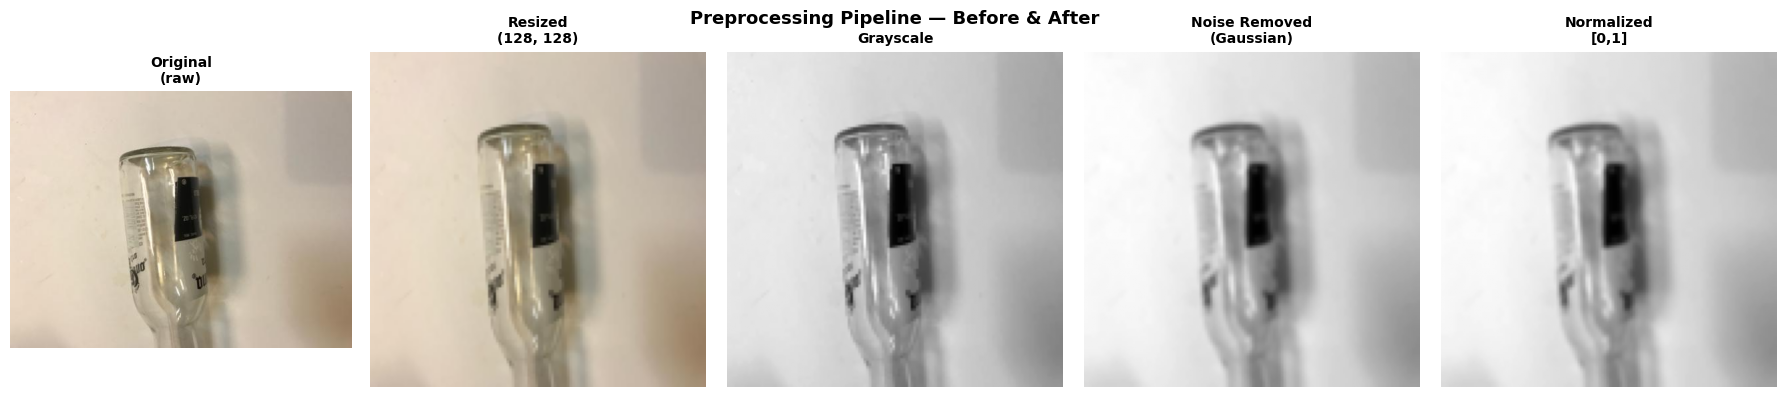

 Before/After preprocessing displayed.


In [ ]:
sample_path = random.choice(all_image_paths)
raw_img   = cv2.imread(sample_path)
raw_img   = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
rgb_resized, gray_norm = preprocess(sample_path)
gray_raw  = to_grayscale(rgb_resized)
blurred   = remove_noise(gray_raw)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Preprocessing Pipeline — Before & After', fontsize=13, fontweight='bold')

steps = [
    (raw_img,     'Original\n(raw)',          None),
    (rgb_resized, f'Resized\n{IMG_SIZE}',     None),
    (gray_raw,    'Grayscale',                'gray'),
    (blurred,     'Noise Removed\n(Gaussian)','gray'),
    (gray_norm,   'Normalized\n[0,1]',        'gray'),
]

for ax, (img, title, cmap) in zip(axes, steps):
    if cmap:
        ax.imshow(img, cmap=cmap)
    else:
        ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Before/After preprocessing displayed.')

---
##  PART 4 — Feature Extraction

We extract **three types of handcrafted features** and concatenate them into a single feature vector:

### 1. HOG (Histogram of Oriented Gradients)
- Captures **shape and edge** information
- Counts occurrences of gradient orientations in localized cells
- Highly effective for object recognition

### 2. LBP (Local Binary Pattern)
- Encodes **texture** by comparing each pixel to its neighbors
- Rotation-invariant and computationally lightweight

### 3. Color Histogram
- Captures **color distribution** in each RGB channel
- Materials like glass and plastic often have distinct color signatures

**Combined Feature Vector = HOG + LBP + Color Histogram**

In [ ]:
def extract_hog_features(gray_img):
    """
    Extract HOG features from a grayscale image.
    Parameters: pixels per cell = (16,16), cells per block = (2,2), orientations = 9
    """
    hog_feats = hog(
        gray_img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        visualize=False,
        feature_vector=True
    )
    return hog_feats


def extract_lbp_features(gray_img, n_points=24, radius=3, n_bins=64):
    """
    Extract LBP texture features.
    Uses 'uniform' method (26 patterns + 1 non-uniform = 27 bins).
    Returns normalized histogram of LBP codes.
    """
    lbp = local_binary_pattern(gray_img, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, n_points + 3),
                           range=(0, n_points + 2))
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-6)
    return hist


def extract_color_histogram(rgb_img, bins=32):
    """
    Extract normalized color histograms for each RGB channel.
    Returns concatenated histogram of shape (bins * 3,).
    """
    hist_feats = []
    for ch in range(3):
        hist, _ = np.histogram(rgb_img[:, :, ch].ravel(),
                               bins=bins, range=(0, 256))
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-6)
        hist_feats.extend(hist)
    return np.array(hist_feats)


def extract_features(path):
    """
    Full feature extraction pipeline for one image.
    Returns combined feature vector: HOG + LBP + Color Histogram
    """
    rgb, gray_norm = preprocess(path)

    gray_uint8 = (gray_norm * 255).astype(np.uint8)

    hog_f   = extract_hog_features(gray_norm)
    lbp_f   = extract_lbp_features(gray_uint8)
    color_f = extract_color_histogram(rgb)

    return np.concatenate([hog_f, lbp_f, color_f])


test_feat = extract_features(all_image_paths[0])
print(' Feature extraction test passed!')
print(f'   HOG features     : {extract_hog_features(normalize(remove_noise(to_grayscale(load_and_resize(all_image_paths[0]))))).shape[0]}')
print(f'   LBP features     : 26')
print(f'   Color hist feats : {32*3}')
print(f'   TOTAL features   : {test_feat.shape[0]}')

 Feature extraction test passed!
   HOG features     : 1764
   LBP features     : 26
   Color hist feats : 96
   TOTAL features   : 1886


In [ ]:
print(' Extracting features for all images...')
print('   (This may take 3–8 minutes depending on dataset size)\n')

LABEL_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: cls for cls, i in LABEL_TO_IDX.items()}

X_all = []
y_all = []
failed = 0

start_time = time.time()
total = len(all_image_paths)

for i, (path, label) in enumerate(zip(all_image_paths, all_labels)):
    try:
        feat = extract_features(path)
        X_all.append(feat)
        y_all.append(LABEL_TO_IDX[label])
    except Exception as e:
        failed += 1
    if (i + 1) % 200 == 0 or (i + 1) == total:
        elapsed = time.time() - start_time
        pct = (i+1)/total*100
        print(f'  [{i+1}/{total}] {pct:.1f}% done — elapsed: {elapsed:.1f}s')

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)

print(f'\n  Feature extraction complete!')
print(f'   Feature matrix shape : {X_all.shape}  (samples × features)')
print(f'   Labels shape         : {y_all.shape}')
print(f'   Failed images        : {failed}')
print(f'   Total time           : {time.time()-start_time:.1f}s')

 Extracting features for all images...
   (This may take 3–8 minutes depending on dataset size)

  [200/2527] 7.9% done — elapsed: 2.9s
  [400/2527] 15.8% done — elapsed: 5.8s
  [600/2527] 23.7% done — elapsed: 9.0s
  [800/2527] 31.7% done — elapsed: 13.4s
  [1000/2527] 39.6% done — elapsed: 16.2s
  [1200/2527] 47.5% done — elapsed: 19.3s
  [1400/2527] 55.4% done — elapsed: 22.5s
  [1600/2527] 63.3% done — elapsed: 27.3s
  [1800/2527] 71.2% done — elapsed: 30.5s
  [2000/2527] 79.1% done — elapsed: 33.4s
  [2200/2527] 87.1% done — elapsed: 36.7s
  [2400/2527] 95.0% done — elapsed: 41.1s
  [2527/2527] 100.0% done — elapsed: 43.5s

  Feature extraction complete!
   Feature matrix shape : (2527, 1886)  (samples × features)
   Labels shape         : (2527,)
   Failed images        : 0
   Total time           : 43.5s


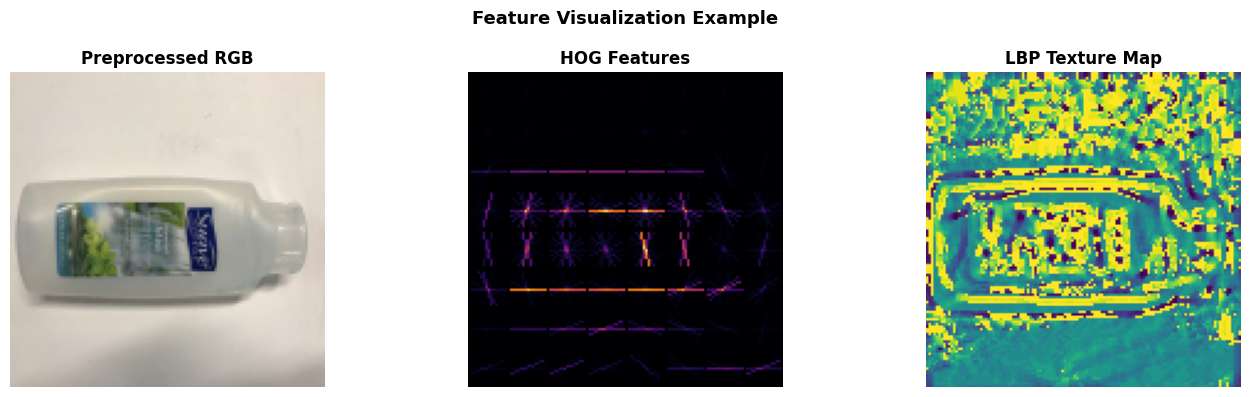

 Feature visualization complete.


In [ ]:
from skimage.feature import hog as hog_vis

sample_path = random.choice(all_image_paths)
rgb, gray_norm = preprocess(sample_path)

_, hog_image = hog_vis(
    gray_norm,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    visualize=True
)

lbp_raw = local_binary_pattern(
    (gray_norm*255).astype(np.uint8), 24, 3, method='uniform')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Feature Visualization Example', fontsize=13, fontweight='bold')

axes[0].imshow(rgb); axes[0].set_title('Preprocessed RGB', fontweight='bold')
axes[1].imshow(hog_image, cmap='inferno'); axes[1].set_title('HOG Features', fontweight='bold')
axes[2].imshow(lbp_raw, cmap='viridis');  axes[2].set_title('LBP Texture Map', fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig('feature_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Feature visualization complete.')

---
##  PART 5 — Train / Validation / Test Split

We split data into three sets:

| Set | Ratio | Purpose |
|-----|-------|---------|
| **Train** | 70% | Model learning |
| **Validation** | 15% | Hyperparameter tuning |
| **Test** | 15% | Final unbiased evaluation |

The split is implemented **manually** using NumPy index shuffling — no sklearn.

In [ ]:
def manual_train_val_test_split(X, y, train_ratio=0.70, val_ratio=0.15, seed=42):
    """
    Splits dataset into train / validation / test sets.
    Implements shuffle via NumPy index permutation.
    """
    np.random.seed(seed)
    n = len(X)
    indices = np.random.permutation(n)

    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    train_idx = indices[:n_train]
    val_idx   = indices[n_train:n_train + n_val]
    test_idx  = indices[n_train + n_val:]

    return (X[train_idx], y[train_idx],
            X[val_idx],   y[val_idx],
            X[test_idx],  y[test_idx])


X_train, y_train, X_val, y_val, X_test, y_test = manual_train_val_test_split(X_all, y_all)

print(' Dataset split complete!')
print(f'   Training set   : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X_all)*100:.1f}%)')
print(f'   Validation set : {X_val.shape[0]}  samples  ({X_val.shape[0]/len(X_all)*100:.1f}%)')
print(f'   Test set       : {X_test.shape[0]}  samples  ({X_test.shape[0]/len(X_all)*100:.1f}%)')
print(f'   Feature dims   : {X_train.shape[1]}')

 Dataset split complete!
   Training set   : 1768 samples  (70.0%)
   Validation set : 379  samples  (15.0%)
   Test set       : 380  samples  (15.0%)
   Feature dims   : 1886


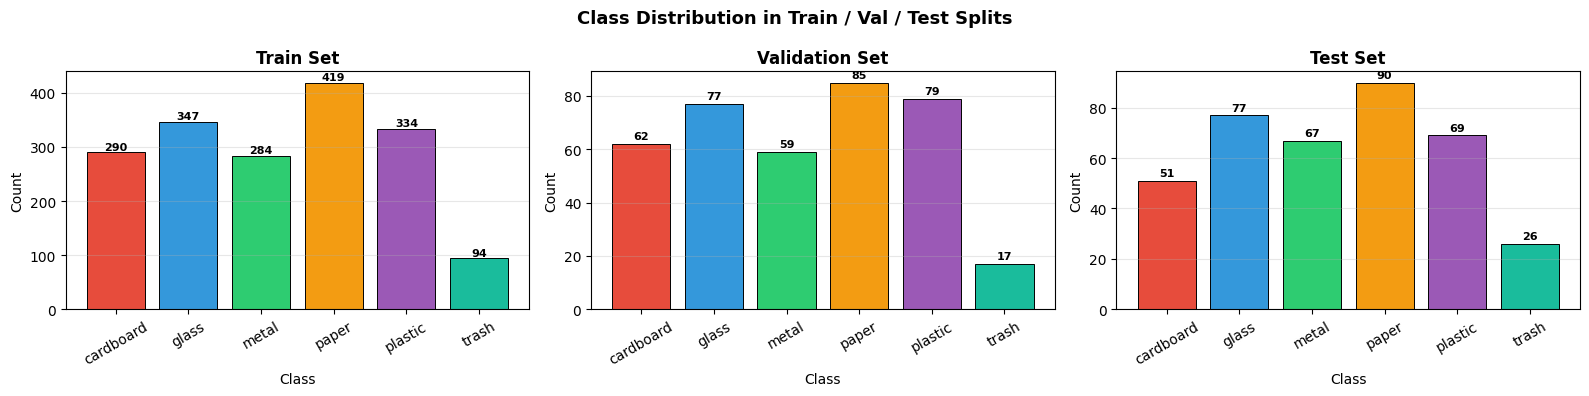

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Class Distribution in Train / Val / Test Splits', fontsize=13, fontweight='bold')

for ax, (y_split, title) in zip(axes, [
    (y_train, 'Train Set'),
    (y_val,   'Validation Set'),
    (y_test,  'Test Set')
]):
    counts = [np.sum(y_split == i) for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, str(cnt),
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  PART 6 — Model 1: K-Nearest Neighbors (KNN) — From Scratch

### Algorithm Overview
KNN is a **lazy learning** algorithm — it does not build a model during training. Instead, when predicting, it:
1. Computes the distance from the query point to all training points
2. Selects the **K nearest** neighbors
3. Predicts by **majority vote**

### Euclidean Distance Formula:
$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

### Majority Vote:
$$\hat{y} = \arg\max_c \sum_{i \in N_K(x)} \mathbf{1}[y_i = c]$$

### Advantages:
- Simple and intuitive
- No training phase
- Naturally handles multi-class problems

### Limitations:
- Slow prediction O(n·d) for each query
- Sensitive to irrelevant features and scale
- High memory usage (stores entire training set)

In [ ]:
class KNNClassifier:
    """
    K-Nearest Neighbors Classifier implemented from scratch.
    Uses Euclidean distance and majority voting.
    NO sklearn used.
    """

    def __init__(self, k=5):
        """
        Parameters
        ----------
        k : int
            Number of nearest neighbors to consider
        """
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        'Training' phase: KNN simply memorizes the training data.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
        y : ndarray of shape (n_samples,)
        """
        self.X_train = np.array(X, dtype=np.float32)
        self.y_train = np.array(y, dtype=np.int32)

    def _euclidean_distances(self, X_query):
        """
        Compute Euclidean distance from each query sample to all training samples.

        Uses the identity:
            ||a - b||^2 = ||a||^2 + ||b||^2 - 2*a·b

        This vectorized form is much faster than a loop.

        Parameters
        ----------
        X_query : ndarray of shape (n_query, n_features)

        Returns
        -------
        distances : ndarray of shape (n_query, n_train)
        """
        sq_query = np.sum(X_query ** 2, axis=1, keepdims=True)
        sq_train = np.sum(self.X_train ** 2, axis=1, keepdims=True).T
        cross    = np.dot(X_query, self.X_train.T)

        dist_sq  = sq_query + sq_train - 2 * cross
        dist_sq  = np.maximum(dist_sq, 0)
        return np.sqrt(dist_sq)

    def predict(self, X, batch_size=50):
        """
        Predict class labels for each sample in X.

        To avoid memory issues with large datasets, we process in batches.

        Parameters
        ----------
        X          : ndarray of shape (n_query, n_features)
        batch_size : int — number of query samples per batch

        Returns
        -------
        predictions : ndarray of shape (n_query,)
        """
        X = np.array(X, dtype=np.float32)
        n_query = X.shape[0]
        predictions = np.zeros(n_query, dtype=np.int32)

        for start in range(0, n_query, batch_size):
            end   = min(start + batch_size, n_query)
            batch = X[start:end]

            distances = self._euclidean_distances(batch)

            sorted_idx = np.argsort(distances, axis=1)[:, :self.k]

            for i, neighbors in enumerate(sorted_idx):
                neighbor_labels = self.y_train[neighbors]
                vote_counts = Counter(neighbor_labels)
                predictions[start + i] = vote_counts.most_common(1)[0][0]

        return predictions

    def score(self, X, y):
        """Return accuracy on (X, y)."""
        preds = self.predict(X)
        return np.mean(preds == y)


print(' KNNClassifier class defined.')
print('   Methods: fit(), predict(), score()')
print('   Distance metric: Euclidean (vectorized via identity trick)')

 KNNClassifier class defined.
   Methods: fit(), predict(), score()
   Distance metric: Euclidean (vectorized via identity trick)


 Tuning K on validation set...
   K= 1  →  Val Accuracy: 50.13%
   K= 3  →  Val Accuracy: 53.03%
   K= 5  →  Val Accuracy: 53.30%
   K= 7  →  Val Accuracy: 48.02%
   K= 9  →  Val Accuracy: 48.81%
   K=11  →  Val Accuracy: 47.49%

  Best K = 5  (Val Acc = 53.30%)


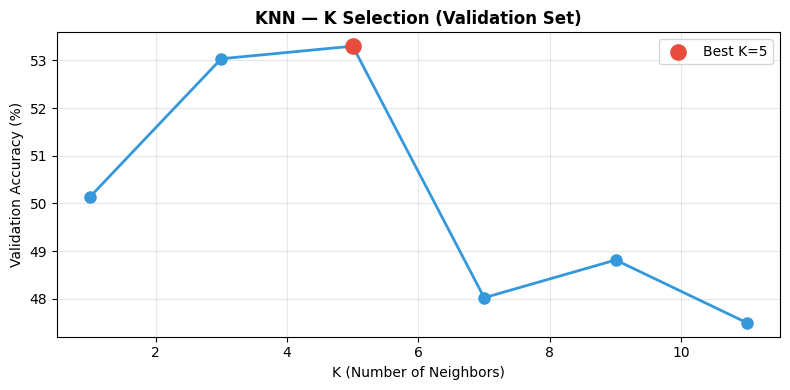

In [ ]:


print(' Tuning K on validation set...')
k_values   = [1, 3, 5, 7, 9, 11]
k_val_accs = []

N_TUNE = min(500, len(X_train))
idx_tune = np.random.choice(len(X_train), N_TUNE, replace=False)

for k in k_values:
    knn_tune = KNNClassifier(k=k)
    knn_tune.fit(X_train[idx_tune], y_train[idx_tune])
    acc = knn_tune.score(X_val, y_val)
    k_val_accs.append(acc)
    print(f'   K={k:>2}  →  Val Accuracy: {acc*100:.2f}%')

best_k = k_values[np.argmax(k_val_accs)]
print(f'\n  Best K = {best_k}  (Val Acc = {max(k_val_accs)*100:.2f}%)')

plt.figure(figsize=(8, 4))
plt.plot(k_values, [a*100 for a in k_val_accs], 'o-', color='#3498db',
         linewidth=2, markersize=8)
plt.scatter([best_k], [max(k_val_accs)*100], color='#e74c3c', s=120,
            zorder=5, label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)'); plt.ylabel('Validation Accuracy (%)')
plt.title('KNN — K Selection (Validation Set)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f' Training final KNN with K={best_k} on full training set...')

knn = KNNClassifier(k=best_k)

t0 = time.time()
knn.fit(X_train, y_train)
knn_train_time = time.time() - t0
print(f'   Training time : {knn_train_time:.4f}s  (memorization only)')

print(' Predicting on test set (may take a moment)...')
t0 = time.time()
y_pred_knn = knn.predict(X_test, batch_size=50)
knn_pred_time = time.time() - t0

knn_acc = np.mean(y_pred_knn == y_test)
print(f'\n KNN Results:')
print(f'   Test Accuracy  : {knn_acc*100:.2f}%')
print(f'   Prediction time: {knn_pred_time:.2f}s  ({len(X_test)} samples)')

 Training final KNN with K=5 on full training set...
   Training time : 0.0063s  (memorization only)
 Predicting on test set (may take a moment)...

 KNN Results:
   Test Accuracy  : 54.74%
   Prediction time: 0.11s  (380 samples)


---
##  PART 7 — Model 2: Gaussian Naïve Bayes — From Scratch

### Algorithm Overview
Naïve Bayes is a **probabilistic classifier** based on Bayes' Theorem with the "naïve" assumption that all features are **conditionally independent** given the class.

### Bayes' Theorem:
$$P(C \mid X) = \frac{P(X \mid C) \cdot P(C)}{P(X)}$$

Since $P(X)$ is constant for all classes, we maximize:
$$\hat{y} = \arg\max_c \left[ \log P(C) + \sum_{i=1}^{n} \log P(x_i \mid C) \right]$$

### Gaussian Likelihood:
$$P(x_i \mid C) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

### Training:
- Compute class **prior** $P(C)$
- Compute per-class per-feature **mean** $\mu$
- Compute per-class per-feature **variance** $\sigma^2$

### Advantages:
- Very fast training and prediction
- Works well with small datasets

### Limitations:
- Naïve independence assumption is often violated
- Poor with highly correlated features

In [ ]:
class GaussianNaiveBayes:
    """
    Gaussian Naïve Bayes Classifier — implemented from scratch.
    NO sklearn used.

    Assumes each feature follows a Gaussian (normal) distribution.
    Uses log-probabilities for numerical stability.
    """

    def __init__(self, var_smoothing=1e-9):
        """
        Parameters
        ----------
        var_smoothing : float
            Small value added to variance to avoid division by zero.
        """
        self.var_smoothing = var_smoothing
        self.classes    = None
        self.log_priors = None
        self.means      = None
        self.variances  = None

    def fit(self, X, y):
        """
        Estimate class priors, per-class means and variances.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
        y : ndarray of shape (n_samples,)
        """
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.int32)

        self.classes    = np.unique(y)
        n_classes       = len(self.classes)
        n_features      = X.shape[1]
        n_samples       = X.shape[0]

        self.means      = np.zeros((n_classes, n_features))
        self.variances  = np.zeros((n_classes, n_features))
        self.log_priors = np.zeros(n_classes)

        for i, cls in enumerate(self.classes):
            X_cls = X[y == cls]

            self.log_priors[i] = np.log(len(X_cls) / n_samples)

            self.means[i]     = np.mean(X_cls, axis=0)

            self.variances[i] = np.var(X_cls, axis=0) + self.var_smoothing

    def _log_gaussian(self, X, cls_idx):
        """
        Compute log-likelihood of X under Gaussian for class cls_idx.

        log P(x_i | C) = -0.5 * log(2π σ²) - (x_i - μ)² / (2σ²)

        Parameters
        ----------
        X       : ndarray (n_samples, n_features)
        cls_idx : int

        Returns
        -------
        log_likelihoods : ndarray (n_samples,)
        """
        mu  = self.means[cls_idx]
        var = self.variances[cls_idx]

        log_lik = -0.5 * np.sum(
            np.log(2 * np.pi * var) + ((X - mu) ** 2) / var,
            axis=1
        )
        return log_lik

    def predict_proba(self, X):
        """
        Compute log-posterior P(C|X) for each class.

        Returns
        -------
        log_posteriors : ndarray (n_samples, n_classes)
        """
        X = np.array(X, dtype=np.float64)
        log_posteriors = np.zeros((X.shape[0], len(self.classes)))
        for i in range(len(self.classes)):
            log_posteriors[:, i] = self._log_gaussian(X, i) + self.log_priors[i]
        return log_posteriors

    def predict(self, X):
        """
        Predict class = argmax of log-posterior.
        """
        log_posteriors = self.predict_proba(X)
        return self.classes[np.argmax(log_posteriors, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


print(' GaussianNaiveBayes class defined.')
print(' Methods: fit(), predict(), predict_proba(), score()')

 GaussianNaiveBayes class defined.
 Methods: fit(), predict(), predict_proba(), score()


In [ ]:
gnb = GaussianNaiveBayes(var_smoothing=1e-9)

t0 = time.time()
gnb.fit(X_train, y_train)
gnb_train_time = time.time() - t0

t0 = time.time()
y_pred_gnb = gnb.predict(X_test)
gnb_pred_time = time.time() - t0

gnb_acc = np.mean(y_pred_gnb == y_test)

print(' Gaussian Naïve Bayes Results:')
print(f'   Training time  : {gnb_train_time:.4f}s')
print(f'   Prediction time: {gnb_pred_time:.4f}s')
print(f'   Test Accuracy  : {gnb_acc*100:.2f}%')

print('\nPer-class learned priors:')
for i, cls in enumerate(CLASS_NAMES):
    prior_pct = np.exp(gnb.log_priors[i]) * 100
    print(f'   {cls:<12}: prior = {prior_pct:.1f}%,  '
          f'mean_feat_μ = {gnb.means[i].mean():.4f},  '
          f'mean_feat_σ² = {gnb.variances[i].mean():.6f}')

 Gaussian Naïve Bayes Results:
   Training time  : 0.0280s
   Prediction time: 0.0193s
   Test Accuracy  : 56.32%

Per-class learned priors:
   cardboard   : prior = 16.4%,  mean_feat_μ = 0.1179,  mean_feat_σ² = 0.010939
   glass       : prior = 19.6%,  mean_feat_μ = 0.1068,  mean_feat_σ² = 0.012186
   metal       : prior = 16.1%,  mean_feat_μ = 0.1069,  mean_feat_σ² = 0.011888
   paper       : prior = 23.7%,  mean_feat_μ = 0.1141,  mean_feat_σ² = 0.011102
   plastic     : prior = 18.9%,  mean_feat_μ = 0.1140,  mean_feat_σ² = 0.010435
   trash       : prior = 5.3%,  mean_feat_μ = 0.1119,  mean_feat_σ² = 0.010515
